# Dynamics of Role-based Passing Networks in Elite Football

MSc Data Science Dissertation - INM363 Individual Project
City St George's, University of London

Supervisor: Dr Gennady Andrienko

## Overview
Analysis of role-based passing networks using the Wyscout public event dataset (Pappalardo et al., 2019). Case study: Manchester City, Premier League 2017/18.

RQ1: Cluster role-based passing networks into tactical variants (UMAP/t-SNE)

RQ2: How do variants evolve across a season?

RQ3: Are variants associated with match outcomes?

## Data Loading & Preparation

In [1]:
#First we import some major libraries

import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from data_loading import(
load_events, load_matches, load_players, load_teams,
get_team_id, filter_matches_for_team, filter_events_for_team,
sanity_check_matches, load_raw_matches,

)
from possession_episodes import segment_season, apply_episode_threshold

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

TEAM_NAME = 'Manchester City'
COMPETITION = 'England'
EXPECTED_N_MATCHES = 38

In [2]:
#This 4 lines load all four raw Wyscout files into pandas dataframes using the functions
#from data_loading.py

teams = load_teams()
players = load_players()
matches = load_matches(competition=COMPETITION)
events = load_events(competition=COMPETITION)

print('teams:', teams.shape)
print('players:', players.shape)
print('matches:', matches.shape)
print('events:', events.shape)

teams: (142, 9)
players: (3603, 22)
matches: (380, 233)
events: (65814, 12)


In [3]:
#Now since we are only focused on Manchester City, we lookup for its ID from teams table

team_id = get_team_id(teams, TEAM_NAME)
print(f'{TEAM_NAME} -> wyId {team_id}')

Manchester City -> wyId 1625


In [4]:
#This block filters out of the 380-match competition table to just the matches
#Manchester City played. Sanity checks are done as well.

team_matches = filter_matches_for_team(matches, team_id)
sanity_check_matches(team_matches, expected_n_matches=EXPECTED_N_MATCHES)
team_matches[['wyId', 'label', 'dateutc', 'venue']].head()

Matches found: 38 (expected: 38)


,wyId,label,dateutc,venue
0,2500095,"Southampton - Manchester City, 0 - 1",2018-05-13 14:00:00,St. Mary's Stadium
1,2500024,"Manchester City - Brighton & Hove Albion, 3 - 1",2018-05-09 19:00:00,Etihad Stadium
2,2500085,"Manchester City - Huddersfield Town, 0 - 0",2018-05-06 12:30:00,Etihad Stadium
3,2500078,"West Ham United - Manchester City, 1 - 4",2018-04-29 13:15:00,London Stadium
4,2500065,"Manchester City - Swansea City, 5 - 0",2018-04-22 15:30:00,Etihad Stadium


In [5]:
#Similar to previous block, we filter the events for Man City

team_events = filter_events_for_team(events, team_id, match_ids=team_matches['wyId'])
print('Events involving', TEAM_NAME, ':', team_events.shape)
team_events.head()

Events involving Manchester City : (41216, 12)


,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],8325,"[{'y': 53, 'x': 49}, {'y': 51, 'x': 36}]",2499720,Pass,1625,1H,3.358676,85,178147292
1,8,Simple pass,[{'id': 1801}],105339,"[{'y': 51, 'x': 36}, {'y': 30, 'x': 28}]",2499720,Pass,1625,1H,5.108462,85,178147293
2,8,Simple pass,[{'id': 1801}],70086,"[{'y': 30, 'x': 28}, {'y': 79, 'x': 28}]",2499720,Pass,1625,1H,7.758945,85,178147294
3,8,Simple pass,[{'id': 1801}],8307,"[{'y': 79, 'x': 28}, {'y': 24, 'x': 28}]",2499720,Pass,1625,1H,11.267789,85,178147295
4,8,Simple pass,[{'id': 1801}],70086,"[{'y': 24, 'x': 28}, {'y': 52, 'x': 38}]",2499720,Pass,1625,1H,15.599964,85,178147296


## Exploratory Data Analysis

In [6]:
#Now, jumping into the EDA, we do a quick check of the data quality for missing values

missing_summary = team_events[['eventSec', 'positions', 'playerId', 'matchId']].isna().sum()
print(missing_summary)

empty_positions = team_events['positions'].apply(lambda p: len(p) == 0 if isinstance(p, list) else True)
print(f'Events with no position data: {empty_positions.sum()} / {len(team_events)}')

eventSec     0
positions    0
playerId     0
matchId      0
dtype: int64
Events with no position data: 0 / 41216


eventName
Pass                       27523
Duel                        7498
Others on the ball          3045
Free Kick                   1695
Shot                         603
Foul                         364
Interruption                 294
Save attempt                  89
Offside                       66
Goalkeeper leaving line       39
Name: count, dtype: int64


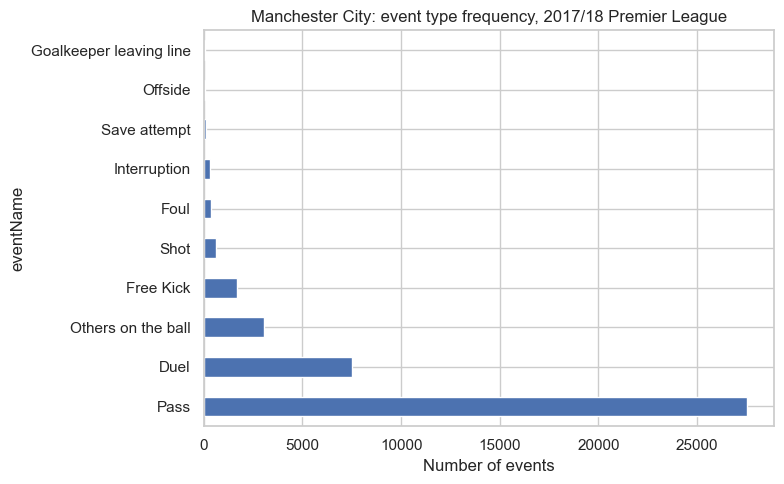

In [7]:
#Here we count the events that fall into each of the categories across all of City's events
#for the season and we create a visualisation.

event_counts = team_events["eventName"].value_counts()
print(event_counts)

fig, ax = plt.subplots(figsize=(8, 5))
event_counts.plot(kind='barh', ax=ax)
ax.set_xlabel("Number of events")
ax.set_title(f"{TEAM_NAME}: event type frequency, 2017/18 Premier League")
plt.savefig('event_type_frequency.png', dpi=150)
plt.tight_layout()
plt.show()

In [8]:
#This block isolates just the pass events and calculates the pass accuracy. So each event has a 'tags' field (a list of
#small dictionaries like "[{'id': 1801}]" ) which encode extra qualifiers about that event, rather than having a seperate
#accuracy column. The Tag ID 1801 means "accurate". The has_tag function checks whether that specific ID appears anywhere
#in a tag list of each event.

passes = team_events[team_events['eventName'] == 'Pass'].copy()

def has_tag(tags, tag_id):
    return any(t.get('id') == tag_id for t in tags) if isinstance(tags, list) else False

passes["accurate"] = passes["tags"].apply(lambda t: has_tag(t, 1801))

print(f"Total {TEAM_NAME} passes across the season: {len(passes)}")
print(f"Average passes per match: {len(passes) / EXPECTED_N_MATCHES:.1f}")
print(f"overall pass accuracy: {passes["accurate"].mean():.1%}")

Total Manchester City passes across the season: 27523
Average passes per match: 724.3
overall pass accuracy: 90.0%


## Possession Episode Segmentation

In [9]:
#The following code runs the segmentation logic from the possession_episodes.py across
#the entire season. We narrow down the result to just Man City's episodes and then apply
#the minimum-passes/duration threshold to strip out the noisy fragments.

MIN_PASSES = 2
MIN_DURATION_SECONDS = 3.0

all_segments = segment_season(events)
print(f'Total raw episodes (both teams, all {EXPECTED_N_MATCHES} matches): {len(all_segments)}')

team_segments = all_segments[all_segments['team_id'] == team_id].copy()
print(f'Raw {TEAM_NAME} episodes: {len(team_segments)}')

valid_episodes = apply_episode_threshold(
    team_segments, min_passes=MIN_PASSES, min_duration=MIN_DURATION_SECONDS
)
print(f'{TEAM_NAME} episodes after threshold (>={MIN_PASSES} passes, .={MIN_DURATION_SECONDS}s): {len(valid_episodes)}')
print(f'Retained: {len(valid_episodes) / len(team_segments):.1%}')

Total raw episodes (both teams, all 38 matches): 10787
Raw Manchester City episodes: 5397
Manchester City episodes after threshold (>=2 passes, .=3.0s): 3048
Retained: 56.5%


Valid episodes per match:
count     38.000000
mean      80.210526
std        8.862792
min       65.000000
25%       72.500000
50%       80.000000
75%       86.750000
max      100.000000
dtype: float64


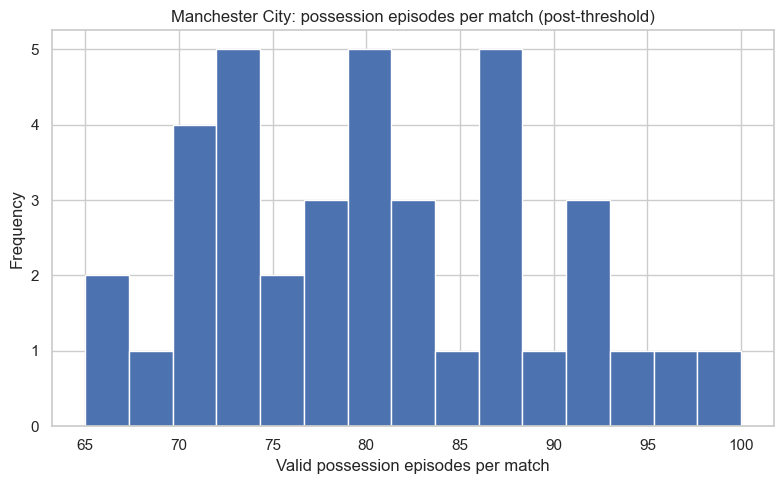

In [10]:
#Here we group the filtered episodes by match and count how many valid episodes fall in each one.
#The results are being shown in a visual

per_match = valid_episodes.groupby('matchId').size()
print('Valid episodes per match:')
print(per_match.describe())

fig, ax = plt.subplots(figsize=(8, 5))
per_match.plot(kind='hist', bins=15, ax=ax)
ax.set_xlabel('Valid possession episodes per match')
ax.set_title(f"{TEAM_NAME}: possession episodes per match (post-threshold)")
plt.tight_layout()
plt.savefig('episodes_per_match.png', dpi=150)
plt.show()

In [11]:
#save the final cleaned version of possession-episode table to disk as a csv.

valid_episodes.to_csv('city_possession_episodes.csv', index=False)
print(valid_episodes.shape)
valid_episodes.head()

(3048, 10)


,segment_id,team_id,period,start,end,n_actions,n_passes,n_events_total,duration,matchId
0,1,1625,1H,3.358676,24.312257,8,8,8,20.953581,2499720
1,9,1625,1H,63.031991,70.488325,2,2,13,7.456334,2499720
2,11,1625,1H,102.005515,189.560864,29,25,31,87.555349,2499720
3,13,1625,1H,196.406208,208.980701,7,7,10,12.574493,2499720
4,15,1625,1H,260.690678,290.389542,9,8,11,29.698864,2499720


## Step 1: Player Role Assignment

Player roles are assigned using each player's average pitch position, computed separately within time segments bounded by substitutions (so substitutes don't get treated as extra competitors alongside the players they replaced). Each of 10 outfield players is matches to one of 10 fixed reference role slots (e.g Defence-Left, Midfield-Centre, Attack-Right) using the Hungarian algorithm for optimal 1-to-1 assignment, which guarantees no two players share a role label within the same segment. Goalkeepers are identified directly from the players reference table rather than by position, since their averagw event location is not a reliable indicator (their distribution events can pull their average position much further upfield thatn their actual role).

In [12]:
from role_assignment import assign_roles_for_match, assign_roles_for_season

In [13]:
raw_matches = load_raw_matches(competition=COMPETITION)

role_assignments = assign_roles_for_season(events, raw_matches, players, team_id)
print(f"Total role assignments (across all segments, all matches): {len(role_assignments)}")

#Quick sanity check that there are no collision between player positions
collision_check = role_assignments.groupby(['matchId', 'segment_id'])['role'].apply(
    lambda r: r.duplicated().any()
)
print(f"Segments with a role collision: {collision_check.sum()} / {len(collision_check)}")

role_assignments.to_csv('city_role_assignments.csv', index=False)

Total role assignments (across all segments, all matches): 1504
Segments with a role collision: 1 / 143
